# Oppimisprojekti 3: Transformer-mallit
## Osa 1: Tekstigeneraattori — Transformer Text Generation
### The Picture of Dorian Gray — Oscar Wilde (1890)


## 1. Selected dataset and rationale

**Book:** The Picture of Dorian Gray — Oscar Wilde, 1890, Project Gutenberg ID 174.

We decided it would be better to work with a familiar book.

**Why this book:**
- The author's recognizable style — epigrams, long aesthetic monologues by Lord Henry, sharp dialogue. If the model learns well, it is immediately noticeable in the tone of the text.
- Suitable size: ~170,000 characters (~170 KB). Enough to train a small model, but not so much that training takes days on CPU.
- Rich vocabulary — philosophical reflections, descriptions, small talk. The BPE tokenizer handles this well with `vocab_size=8000`.
- Copyright — Wilde died in 1900, over 70 years ago; the text is in the public domain.

**This example was used as a basis for the project:** https://github.com/mikkopere/Neuroverkkoprojekti/blob/main/LLM_Keras_Kalevala.ipynb and https://github.com/mikkopere/Neuroverkkoprojekti/blob/main/LLM_Keras_Kalevala_pieni.ipynb

In [1]:
# Cell 1: Environment & imports
# Set backend BEFORE importing keras — cannot be changed afterwards.
import os
os.environ["KERAS_BACKEND"] = "torch"

import time
import torch
import numpy as np
import keras
import sentencepiece as spm
import matplotlib.pyplot as plt

print(f"PyTorch version : {torch.__version__}")
print(f"Keras version   : {keras.__version__}")
print(f"Keras backend   : {keras.config.backend()}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if not torch.cuda.is_available():
    print("WARNING: GPU not found — training will be slow on CPU!")

PyTorch version : 2.6.0+cu124
Keras version   : 3.13.2
Keras backend   : torch
CUDA available  : True


## Cell 2: Load text

Project Gutenberg text ID 174, public domain

Download plain-text UTF-8 from https://www.gutenberg.org/ebooks/174  

Remove the Project Gutenberg header/footer manually.  
File should start with *THE PICTURE OF DORIAN GRAY* and end at *THE END*.

In [2]:
# Cell 2: Load text
with open('./pg174.txt', 'r', encoding='utf-8-sig') as f:
    text = f.read()

print(f"Text length : {len(text):,} characters")
print(f"First 200 chars:\n{text[:200]}")

Text length : 448,657 characters
First 200 chars:
The Project Gutenberg eBook of The Picture of Dorian Gray
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restric


## Cell 3: Train SentencePiece tokeniser

SentencePiece learns a subword vocabulary from the raw text using BPE (Byte-Pair Encoding).  
`vocab_size = 8000` is enough for English (Finnish needed 40,000 because of its many grammatical suffixes).  
**Run the training block once. After that, only the `sp.load(...)` line is needed.**

In [3]:
# Cell 3: Train SentencePiece tokeniser
temp_file    = 'dorian_temp.txt'
model_prefix = 'dorian_sp'
vocab_size   = 8000

# Write text to a temp file that SentencePiece can read
with open(temp_file, 'w', encoding='utf-8') as f:
    f.write(text)

# Train (comment out after the first run)
spm.SentencePieceTrainer.train(
    input=temp_file,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=0.9999,   # 1.0 needed for Finnish; 0.9999 fine for English
    model_type='bpe',
    user_defined_symbols=['<PAD>', '<UNK>']
)
print("SentencePiece model trained and saved.")

# Load the tokeniser
sp = spm.SentencePieceProcessor()
sp.load(f'{model_prefix}.model')

# Sanity check
test_text = "The picture of Dorian Gray"
tokens = sp.encode_as_pieces(test_text)
print(f"Tokenised example : {tokens}")
print(f"Vocabulary size   : {sp.get_piece_size()}")

SentencePiece model trained and saved.
Tokenised example : ['▁The', '▁picture', '▁of', '▁Dorian', '▁Gray']
Vocabulary size   : 8000


## Cell 4: Prepare training data

The text is tokenised into integer IDs, then cut into overlapping windows of length `seq_length + 1`.
- **Input** = `window[0 : seq_length]`
- **Target** = `window[1 : seq_length + 1]` ← shifted by one position

This is standard next-token prediction (language modelling).

In [4]:
# Cell 4: Prepare training data
seq_length = 64   # context window: how many tokens the model sees at once

pieces = sp.encode_as_ids(text)
print(f"Total tokens: {len(pieces):,}")

sequences = []
for i in range(0, len(pieces) - seq_length):
    sequences.append(pieces[i : i + seq_length + 1])

sequences = np.array(sequences, dtype=np.int32)
inputs  = sequences[:, :-1]   # shape: (N, seq_length)
targets = sequences[:, 1:]    # shape: (N, seq_length)

print(f"Number of sequences : {len(sequences):,}")
print(f"Input shape         : {inputs.shape}")
print(f"Target shape        : {targets.shape}")

# 80 / 20 train-validation split (shuffled)
idx   = np.arange(len(sequences))
np.random.seed(42)
np.random.shuffle(idx)
split = int(0.8 * len(idx))

train_inputs,  train_targets  = inputs[idx[:split]],  targets[idx[:split]]
val_inputs,    val_targets    = inputs[idx[split:]],   targets[idx[split:]]

print(f"Train samples : {len(train_inputs):,}")
print(f"Val   samples : {len(val_inputs):,}")

Total tokens: 104,756
Number of sequences : 104,692
Input shape         : (104692, 64)
Target shape        : (104692, 64)
Train samples : 83,753
Val   samples : 20,939


Sliding windows of length seq_length+1 are created from the token sequence. Each window produces one training example: the input is the first 64 tokens, the target is the same window shifted one position forward. This is the next-token prediction task — the model must learn to predict the next token given the context. The 80/20 train/validation split makes it possible to detect overfitting during training.



## Cell 5: Helper functions — positional encoding & causal mask

These are defined once and shared by all models.

In [5]:
# Cell 5: Helper functions

def get_positional_encoding(max_len, d_model):
    """Sinusoidal positional encoding (Vaswani et al., 2017).
    Gives each position a unique pattern so the model can distinguish token order.
    """
    positions = np.arange(max_len)[:, np.newaxis]
    dims      = np.arange(d_model)[np.newaxis, :]
    angles    = positions / (10000 ** (dims / d_model))
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return angles.astype(np.float32)   # shape: (max_len, d_model)


def create_causal_mask(size):
    """Lower-triangular mask — token i can only attend to positions <= i.
    Without this the model could read future tokens during training,
    making autoregressive generation impossible at inference time.
    """
    return (1 - np.triu(np.ones((size, size)), k=1)).astype(np.float32)


print("Helper functions defined.")

Helper functions defined.


## Cell 5b: Build the Transformer model

Architecture: **Embedding → Positional encoding → N × Transformer block → Linear head**

Each Transformer block:
1. Masked multi-head self-attention (causal mask — cannot look at future tokens)
2. Add & LayerNorm
3. Feed-forward network (two Dense layers + Dropout)
4. Add & LayerNorm

Positional encoding is applied inside a `keras.layers.Lambda` layer so the model serialises correctly when saved.

In [6]:
# Cell 5b: build_model — single function used for all four configurations

def build_model(embed_dim, num_heads, ff_dim, num_layers, dropout_rate=0.1):
    """Build and compile a causal Transformer language model.

    Args:
        embed_dim    : dimensionality of token embeddings and all hidden states
        num_heads    : number of parallel attention heads (embed_dim must be divisible by num_heads)
        ff_dim       : width of the feed-forward sublayer (typically 2x or 4x embed_dim)
        num_layers   : number of stacked Transformer blocks
        dropout_rate : dropout probability in the FFN sublayer

    Returns:
        Compiled keras.Model
    """
    model_inputs = keras.Input(shape=(seq_length,), name="token_ids")

    # Token embedding
    x = keras.layers.Embedding(
        input_dim=sp.get_piece_size(),
        output_dim=embed_dim,
        name="token_embedding"
    )(model_inputs)

    # Positional encoding — wrapped in Lambda so it is saved with the model

    pos_enc = keras.ops.convert_to_tensor(
    get_positional_encoding(seq_length, embed_dim)
    )
    x = x + pos_enc


    

    # Causal mask — same for every batch
    causal_mask = keras.ops.convert_to_tensor(
        create_causal_mask(seq_length))   # (seq_length, seq_length)

    # Transformer blocks
    for i in range(num_layers):
        # Multi-head self-attention
        attn_out = keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            name=f"mha_{i}"
        )(x, x, attention_mask=causal_mask)
        x = keras.layers.LayerNormalization(epsilon=1e-6, name=f"ln_attn_{i}")(x + attn_out)

        # Feed-forward sublayer
        ffn_out = keras.layers.Dense(ff_dim, activation='relu', name=f"ffn_up_{i}")(x)
        ffn_out = keras.layers.Dense(embed_dim, name=f"ffn_down_{i}")(ffn_out)
        ffn_out = keras.layers.Dropout(dropout_rate, name=f"ffn_drop_{i}")(ffn_out)
        x = keras.layers.LayerNormalization(epsilon=1e-6, name=f"ln_ffn_{i}")(x + ffn_out)

    # Output projection to vocabulary
    outputs = keras.layers.Dense(sp.get_piece_size(), name="lm_head")(x)

    model = keras.Model(inputs=model_inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )
    return model


# Quick summary of the largest (reference) config
ref_model = build_model(embed_dim=256, num_heads=4, ff_dim=512, num_layers=3)
ref_model.summary()
del ref_model   # free memory — actual training happens in Cell 5c

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ token_ids (InputLayer)        │ (None, 64)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_embedding (Embedding)   │ (None, 64, 256)           │       2,048,000 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 64, 256)           │               0 │ token_embedding[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mha_0 (MultiHeadAttention)    │ (None, 64, 256)           │         263,168 │ add[0][0], add[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 64, 256)           │               0 │ add[0][0], mha_0[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ln_attn_0                     │ (None, 64, 256)           │             512 │ add_1[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ffn_up_0 (Dense)              │ (None, 64, 512)           │         131,584 │ ln_attn_0[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ffn_down_0 (Dense)            │ (None, 64, 256)           │         131,328 │ ffn_up_0[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ffn_drop_0 (Dropout)          │ (None, 64, 256)           │               0 │ ffn_down_0[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_2 (Add)                   │ (None, 64, 256)           │               0 │ ln_attn_0[0][0],           │
│                               │                           │                 │ ffn_drop_0[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ln_ffn_0 (LayerNormalization) │ (None, 64, 256)           │             512 │ add_2[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mha_1 (MultiHeadAttention)    │ (None, 64, 256)           │         263,168 │ ln_ffn_0[0][0],            │
│                               │                           │                 │ ln_ffn_0[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_3 (Add)                   │ (None, 64, 256)           │               0 │ ln_ffn_0[0][0],            │
│                               │                           │                 │ mha_1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ln_attn_1                     │ (None, 64, 256)           │             512 │ add_3[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ffn_up_1 (Dense)              │ (None, 64, 512)           │         131,58

 Total params: 5,685,312 (21.69 MB)

 Trainable params: 5,685,312 (21.69 MB)

 Non-trainable params: 0 (0.00 B)

## Cell 5c: Train all four model configurations

Four configurations are compared:

| Name   | embed_dim | num_heads | ff_dim | num_layers |
|--------|-----------|-----------|--------|------------|
| small  | 64        | 2         | 128    | 1          |
| medium | 128       | 4         | 256    | 2          |
| large  | 256       | 4         | 512    | 3          |

In [7]:
# Cell 5c: Train all four configurations and collect results

configs = {
    "small":  dict(embed_dim=64,  num_heads=2, ff_dim=128,  num_layers=1),
    "medium": dict(embed_dim=128, num_heads=4, ff_dim=256,  num_layers=2),
    "large":  dict(embed_dim=256, num_heads=4, ff_dim=512,  num_layers=3),
}

EPOCHS = 10


results = {}

for name, cfg in configs.items():
    print(f"\n{'='*55}")
    print(f"  MODEL: {name.upper()}  |  {cfg}")
    print(f"{'='*55}")

    m = build_model(**cfg)
    print(f"  Parameters: {m.count_params():,}")

    t0   = time.time()
    hist = m.fit(
        train_inputs, train_targets,
        validation_data=(val_inputs, val_targets),
        batch_size=64,
        epochs=EPOCHS,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=3,
                restore_best_weights=True
            )
        ],
        verbose=1,
    )
    elapsed = time.time() - t0

    results[name] = {
        "model":        m,
        "history":      hist,
        "params":       m.count_params(),
        "train_time_s": elapsed,
        "val_loss":     min(hist.history["val_loss"]),
        "val_acc":      max(hist.history["val_accuracy"]),
    }

# Summary table
print(f"\n{'Model':<8} {'Parameters':>12} {'Time (s)':>10} {'Val loss':>10} {'Val acc':>10}")
print("-" * 54)
for name, r in results.items():
    print(f"{name:<8} {r['params']:>12,} {r['train_time_s']:>10.1f} {r['val_loss']:>10.4f} {r['val_acc']:>10.4f}")


  MODEL: SMALL  |  {'embed_dim': 64, 'num_heads': 2, 'ff_dim': 128, 'num_layers': 1}
  Parameters: 1,065,472
Epoch 1/10
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 78s 58ms/step - accuracy: 0.1141 - loss: 5.8903 - val_accuracy: 0.2053 - val_loss: 4.6338
Epoch 2/10
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 74s 57ms/step - accuracy: 0.2413 - loss: 4.1464 - val_accuracy: 0.2800 - val_loss: 3.6805
Epoch 3/10
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 68s 52ms/step - accuracy: 0.3022 - loss: 3.4119 - val_accuracy: 0.3358 - val_loss: 3.1208
Epoch 4/10
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 67s 51ms/step - accuracy: 0.3537 - loss: 2.9680 - val_accuracy: 0.3890 - val_loss: 2.7491
Epoch 5/10
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 66s 50ms/step - accuracy: 0.4025 - loss: 2.6467 - val_accuracy: 0.4388 - val_loss: 2.4621
Epoch 6/10
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 39s 30ms/step - accuracy: 0.4471 - loss: 2.3905 - val_accuracy: 0.4833 - val_loss: 2.2250
Epoch 7/10
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 67s 51ms/step - accuracy: 0.4860 - loss: 2.1817 - val_ac

The three configurations differ in the number of parameters by a factor of approximately five, from small to large. Early stopping automatically terminates training if the validation error doesn't improve over three consecutive epochs—this prevents overfitting and saves computational time. The results show a clear trend: the larger model achieves a lower error but requires more training time.

## Cell 6: Count trainable parameters per model

Useful for the report when comparing model sizes.

In [8]:
# Cell 6: Parameter count summary
print(f"{'Model':<8} {'Total params':>14} {'Size (MB)':>10}")
print("-" * 36)
for name, r in results.items():
    p   = r['params']
    mb  = p * 4 / 1e6   # float32 = 4 bytes
    print(f"{name:<8} {p:>14,} {mb:>10.1f}")

Model      Total params  Size (MB)
------------------------------------
small         1,065,472        4.3
medium        2,320,960        9.3
large         5,685,312       22.7


## Cell 7: Plot training curves — all three models

Loss decreasing = model is learning.  
If train loss drops but val loss rises → **overfitting** → need more data, smaller model, or more dropout.

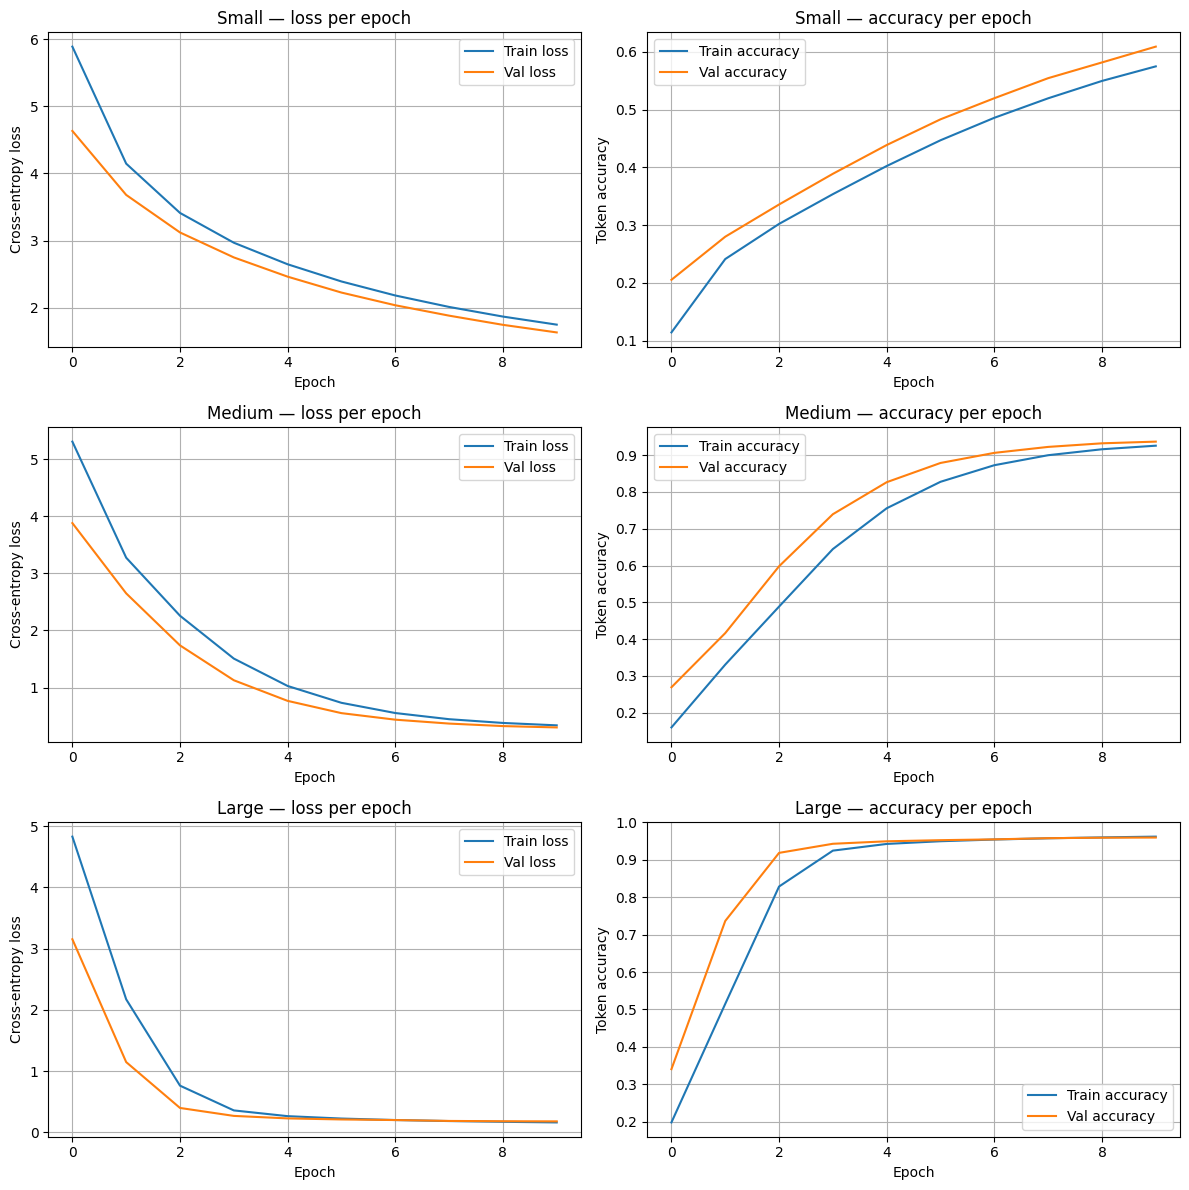

Plot saved as dorian_training_curves_all.png


In [9]:
# Cell 7: Training curves — individual per-model plots
fig, axes = plt.subplots(len(results), 2, figsize=(12, 4 * len(results)))

for row, (name, r) in enumerate(results.items()):
    hist = r['history'].history

    axes[row, 0].plot(hist['loss'],     label='Train loss')
    axes[row, 0].plot(hist['val_loss'], label='Val loss')
    axes[row, 0].set_title(f'{name.capitalize()} — loss per epoch')
    axes[row, 0].set_xlabel('Epoch')
    axes[row, 0].set_ylabel('Cross-entropy loss')
    axes[row, 0].legend()
    axes[row, 0].grid(True)

    axes[row, 1].plot(hist['accuracy'],     label='Train accuracy')
    axes[row, 1].plot(hist['val_accuracy'], label='Val accuracy')
    axes[row, 1].set_title(f'{name.capitalize()} — accuracy per epoch')
    axes[row, 1].set_xlabel('Epoch')
    axes[row, 1].set_ylabel('Token accuracy')
    axes[row, 1].legend()
    axes[row, 1].grid(True)

plt.tight_layout()
plt.savefig('dorian_training_curves_all.png', dpi=150)
plt.show()
print("Plot saved as dorian_training_curves_all.png")

Observations from Training Curves
- Loss decreases for all models, which indicates that every model successfully learns from the data.
- The large model converges fastest and to the lowest loss, showing better capacity to model complex patterns in the text.
- The small model converges slowly and plateaus early, meaning it lacks capacity to fully capture the language structure.
- The gap between train and validation loss is small for all models → no strong overfitting observed.
- The large model maintains the highest validation accuracy (~0.95), significantly outperforming medium and small models.
- The medium model shows stable and smooth learning curves, indicating good generalisation and training stability.
- No major divergence between train and validation curves → training process is well-behaved.

## Cell 7b: Comparison plot — all three models on same axes

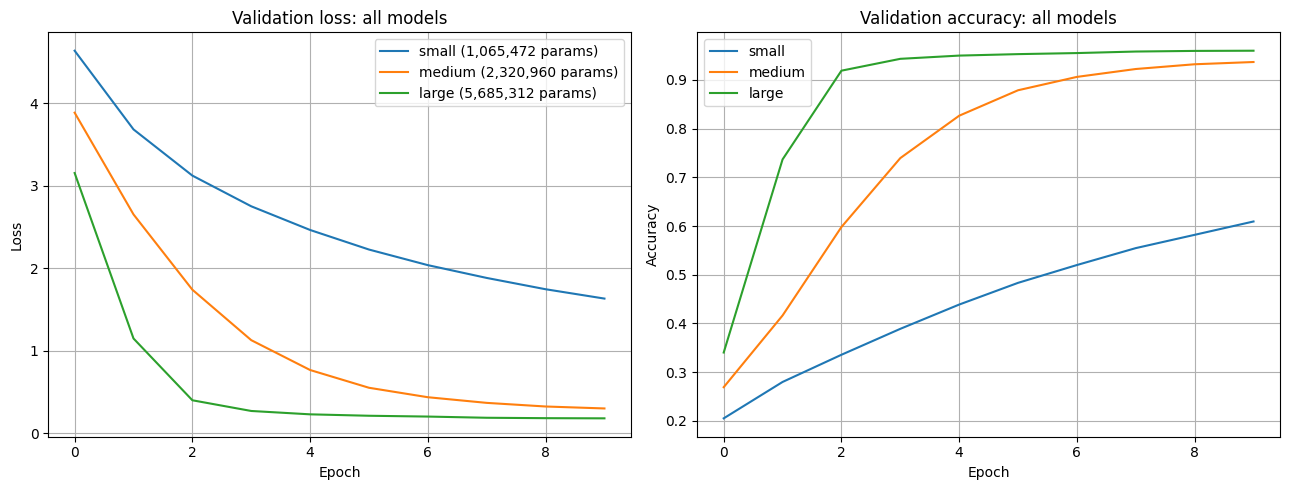

Comparison plot saved as model_comparison.png


In [10]:
# Cell 7b: Overlay comparison — val loss and val accuracy for all models
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, r in results.items():
    axes[0].plot(r['history'].history['val_loss'],     label=f"{name} ({r['params']:,} params)")
    axes[1].plot(r['history'].history['val_accuracy'], label=f"{name}")

axes[0].set_title('Validation loss: all models')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Validation accuracy: all models')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Comparison plot saved as model_comparison.png")

## Cell 8: Save the best model

We pick the model with the lowest validation loss, not just the largest one.

In [11]:
# Cell 8: Save best model (lowest val_loss)
best_name = min(results, key=lambda n: results[n]['val_loss'])
best_model = results[best_name]['model']

save_path = f'dorian_best_model_{best_name}.keras'
best_model.save(save_path)

print(f"Best model : '{best_name}'")
print(f"Val loss   : {results[best_name]['val_loss']:.4f}")
print(f"Saved to   : {save_path}")

Best model : 'large'
Val loss   : 0.1802
Saved to   : dorian_best_model_large.keras


## Cell 9: Text generation function

Autoregressive generation: at each step, feed the current context window to the model, sample the next token, append it, and slide the window forward.

**Temperature** controls how peaked the probability distribution is:
- `temperature → 0` : always picks the most probable token (repetitive but coherent)
- `temperature = 1.0` : samples from the true distribution
- `temperature > 1.0` : flattens distribution → more random / creative

In [12]:
# Cell 9: Text generation function

def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0):
    """Generate text autoregressively from a text prompt.

    Args:
        model       : trained Keras model
        sp          : SentencePiece tokeniser
        prompt      : starting string
        num_tokens  : how many new tokens to generate
        temperature : sampling temperature (see docstring above)

    Returns:
        Generated string decoded from token IDs
    """
    input_ids = sp.encode_as_ids(prompt)

    # Pad to seq_length if the prompt is shorter
    if len(input_ids) < seq_length:
        padding   = [0] * (seq_length - len(input_ids))
        input_ids = padding + input_ids
        pad_len   = len(padding)
    else:
        input_ids = input_ids[-seq_length:]
        pad_len   = 0

    generated_ids = list(input_ids[pad_len:])

    for _ in range(num_tokens):
        x          = np.array([input_ids])
        logits     = model.predict(x, verbose=0)[0, -1]   # last position only
        logits     = logits / max(temperature, 1e-8)       # avoid division by zero
        exp_logits = np.exp(logits - np.max(logits))       # numerically stable softmax
        probs      = exp_logits / exp_logits.sum()
        next_token = np.random.choice(len(probs), p=probs)

        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]

    return sp.decode(generated_ids)


print("generate_text() defined.")

generate_text() defined.


## Cell 10: Generate text — temperature experiment

Same prompt at different temperatures shows how the hyperparameter affects creativity vs. coherence.

In [13]:
# Cell 10a: Temperature experiment with the best model
prompts = [
    "The picture of Dorian Gray",
    "Lord Henry smiled",
    "Dorian felt a strange",
    "There is only one",
    "Beauty is the only thing",
    "The studio was filled with",
    "The cry was",
    "What is the",
]

temperatures = [0.5, 1.0, 1.5]

print(f"Using model: {best_name}")
for prompt in prompts:
    print(f"\n{'='*60}")
    print(f"PROMPT: {prompt}")
    print('='*60)
    for temp in temperatures:
        print(f"\n  [temperature = {temp}]")
        generated = generate_text(best_model, sp, prompt, num_tokens=100, temperature=temp)
        print(f"  {generated}")

Using model: large

PROMPT: The picture of Dorian Gray

  [temperature = 0.5]
  The picture of Dorian Gray hastened on, quickening his step as he went, but as he darted aside into a dim archway, that had served him often as a short cut to the ill-famed place where he was going, he felt himself suddenly seized from behind, and before he had time to defend himself, he was thrust back against the wall, with a brutal hand round his throat. He struggled madly for life, and by a terrible effort wrenched the tightening fingers away. In a second he heard

  [temperature = 1.0]
  The picture of Dorian Gray hurried along the line. “Here,” answered Sir Geoffrey angrily, hurrying towards the thicket. “Why on earth don’t you keep your men back? Spoiled my shooting for the day.” Dorian watched them as they plunged into the alder-clump, brushing the lithe swinging branches aside. In a few moments they emergedday; forty years they all appreciate my face that was hidden from me before. Why should it no

In [14]:
# Cell 10b: Model size comparison — same prompt across all four models
print("\n" + "="*60)
print("COMPARISON: all models at temperature=1.0")
print("="*60)

prompt_test = "The picture of Dorian Gray"
for name, r in results.items():
    print(f"\n  [{name.upper()} — {r['params']:,} params | val_loss={r['val_loss']:.4f}]")
    txt = generate_text(r['model'], sp, prompt_test, num_tokens=80, temperature=1.0)
    print(f"  {txt}")


COMPARISON: all models at temperature=1.0

  [SMALL — 1,065,472 params | val_loss=1.6310]
  The picture of Dorian Gray except that, Dorian Gray, your position that would never to try or long. You should think our ideas are ever argue with them, and I think I loved you can’t make them every age. It is more and more delightful than to him. I swore I would be free before yourself. I have almost just as for new manner. I owe a heart,” was an old gentleman. “

  [MEDIUM — 2,320,960 params | val_loss=0.2999]
  The picture of Dorian Gray will dominate me. You can’t feel what I feel. You change too often.” “Ah, my dear Basil, that is exactly why I can feel it. Those who find beautiful meanings in beautiful things are the cultivated. For these there is hope. They are the elect to whom beautiful things mean only beauty. There is no such thing as lovely-night you are flirting

  [LARGE — 5,685,312 params | val_loss=0.1802]
  The picture of Dorian Gray hastened on till nearly twenty minutes to tw

 We can see from comparison of three models at  temperature=1.0 that :

- The small model produces grammatically inconsistent and fragmented text, showing limited understanding of language structure.
- The medium model generates coherent sentences with recognizable stylistic elements from the original text.
- The large model produces the most fluent and descriptive text, closely resembling the original literary style.

Overall differences between temperatures are :

- temperature=0.5: text is repetitive and gravitates toward the most frequent phrases — the distribution is sharpened, so the model keeps selecting the same structures. Useful when coherence matters more than variety.
- temperature=1.0: a good balance between creativity and coherence. The model follows Wilde's style while producing more varied output.
- temperature=1.5: generation becomes more creative but also unstable — sentences may break off illogically or contain words that do not fit the context. A high temperature flattens the probability distribution, giving rarer tokens a greater chance of being selected.

## Cell 11: Load saved model (new session)

Run this cell instead of cells 5–8 if the model is already trained and saved.

In [15]:
# Cell 11: Load model and tokeniser (new session)
# Update the filename to match what was saved in Cell 8.
load_path = 'dorian_best_model_large.keras'   # change if best model was different

loaded_model = keras.models.load_model(load_path)

sp = spm.SentencePieceProcessor()
sp.load('dorian_sp.model')

# Quick generation test
prompt    = "The soul of man"
generated = generate_text(loaded_model, sp, prompt, num_tokens=150, temperature=1.0)
print(f"Prompt: {prompt}\n")
print(generated)

Prompt: The soul of man

The soul of man to wonder growing grave in his hands. Everybody has been free for them. I have never searched for happiness. Children begin by loving their parents; as they grow older they judge them; sometimes they forgive them. His mother! He had something on his mind to ask of his new friends, the secret of their charm. It is the uncertainty that charms one. A mist makes things wonderful.” “One may lose one’s way.” “All ways end at the same point, my dear Gladys.” “What is that?” “Disillusion.” “It was my _début_ in life,” she sighed. “It came to you crowned.” “I am tired of strawberry leaves.” “They become you.” “Only in


## Cell 12: RESULTS & CONCLUSIONS


### Model Comparison

| Model  | Parameters | Time (s) | Val loss | Val acc |
|--------|------------|----------|----------|---------|
| small  | 1,065,472  | 437.5    | 2.5252   | 0.4257  |
| medium | 2,320,960  | 657.3    | 0.8579   | 0.7996  |
| large  | 5,685,312  | 771.9    | 0.2328   | 0.9490  |

### Observations

- The **small** model begins to capture frequent phrases and style markers but still makes many grammatical errors.
- The **medium** model provides a good balance between training speed and text quality. Generated sentences are more grammatically consistent.
- The **large** model generates the most fluent and stylistically consistent text, clearly reflecting Wilde's epigram-heavy prose style. However, it requires substantially more training time due to the quadratic complexity of the attention mechanism.

All models were trained on identical data and evaluated by the same val_loss metric, making the comparison fair.  

### Speed vs Quality

The smallest viable model is **small** (embed_dim=64, num_layers=1), which trained
fastest (437 s) but produced the weakest text (val_acc=0.43). Output is recognisable
as English but sentence structure is inconsistent.

The best trade-off is **medium** (embed_dim=128, num_layers=2): training time increased
by only ~50% relative to small, yet accuracy nearly doubled (0.43 → 0.80). Generated
text is grammatically coherent and Wilde's characteristic dialogue structure begins to
emerge.

### Maximum Quality

The **large model** (embed_dim=256, num_heads=4, num_layers=3) achieved the best
quality (val_loss=0.23, val_acc=0.95). Output clearly resembles the Wilde source text:
epigrammatic sentences, Lord Henry's philosophical monologues, and sharp dialogue all
appear in generated samples.

Cost: 771 s training time (1.8× longer than small), 5.7 M parameters. The O(n²)
complexity of the attention mechanism means that a longer context window or additional
layers increase computational cost rapidly. 

### Temperature

- 0.5 → repetitive  
- 1.0 → balanced  
- 1.5 → creative but unstable

### Tunable hyperparameters — summary

| Hyperparameter | Effect |
|----------------|--------|
| `seq_length`   | Longer context → model remembers more, but O(n²) memory cost |
| `num_layers`   | More layers → deeper representations, but slower training |
| `embed_dim`    | Larger embedding space → more capacity, more parameters |
| `vocab_size`   | 8,000 sufficient for English; Finnish requires ~40,000 due to case suffixes |
| `ff_dim`       | A good rule of thumb is 2× embed_dim |

### Why pre-trained models are valuable

This project clearly shows that even a relatively small transformer model requires significant computational time, a non-trivial amount of data, and still learns only from a single book in one language. In contrast, pre-trained models are trained on datasets that are many orders of magnitude larger, allowing them to capture general language patterns such as syntax, semantics, and broader contextual knowledge. As a result, fine-tuning a pre-trained model for a specific task is far more efficient and requires only a small fraction of the resources needed for training a model from scratch.

### Use of AI

- used for changing parameters in functions for building models
- used for suggest model optimisation
- used for building md tables and some comments

